In [80]:
import yfinance as yf
import datetime as dt 
import pandas as pd
import numpy as np
from scipy import stats
import json 
import math
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import acf

In [8]:
# if you want to download the data the only use this part
#Downloading the data of S&P 500 from yfinance
start = dt.datetime.now() - dt.timedelta(days = 365*20)
end = dt.datetime.now()
file =r"C:\Users\BROTHER COMPUTER\Desktop\GIT_Project\Quant\S&P500\data\S&P500.xlsx"
SP = yf.download("^GSPC", start = start, end =  end,auto_adjust=False)
SP.to_excel(file)

#if you want to extract and clean the data then only use this part
# after this we will use model importer (a python program which search the module and append it in the system)
import module_importing as mi
mi.find_and_add_module("data_refine")

#after that we will refine the excel file to another new excel file extracting the required columns only 
import data_refine as dr
des_file = dr.choose()

with open(r"C:\Users\BROTHER COMPUTER\Desktop\GIT_Project\Quant\S&P500\data\config.json","w") as f:
    json.dump({"last_path": des_file},f)






[*********************100%***********************]  1 of 1 completed


Searching for 'data_refine.py'...
Searching in: C:\Users\BROTHER COMPUTER

✓ Found module at: C:\Users\BROTHER COMPUTER\Desktop\GIT_Project\Gold\Code\data_refine.py
✓ Directory already in sys.path: C:\Users\BROTHER COMPUTER\Desktop\GIT_Project\Gold\Code


How many excel file data do you want to clean: 1
how many numbers columns do you want to refine: 2
Enter the word which you want to extract the data of in column: Date


found the 'Date' in 3 row 


is it only numeric data or not. if yes then tyoe 'y' and if no , type 'n' n


...

Enter the word which you want to extract the data of in column: Adj Close


found the 'Adj Close' in 1 row 


is it only numeric data or not. if yes then tyoe 'y' and if no , type 'n' y


Successfully extracted data to: C:/Users/BROTHER COMPUTER/Desktop/GIT_Project/Quant/S&P500/data/Cleaned_S&P.xlsx


Do you need the output file's path?y or n: y


In [81]:
with open(r"C:\Users\BROTHER COMPUTER\Desktop\GIT_Project\Quant\S&P500\data\config.json","r") as f:
    config = json.load(f)
    dest_file = config["last_path"]
#after this we will calculate the compounding rolling return 
def calculate_the_return(value):
    #here value is list or series of the data points of days
    retrn = value[-1]/value[0] - 1
    return retrn

def rolling_return(data, window_period):
    return_data = []
    data = data.tolist()
    for i in range(len(data)):
        if i < window_period-1:
            return_data.append(None)
        else:
            value = data[ i - window_period + 1: i + 1]
            result = calculate_the_return(value)
            return_data.append(result)
            '''rolling_12m = (
    (1 + daily_returns)
    .rolling(252)
    .apply(np.prod, raw=True) - 1
    this is the panda method to do and it is shortcut method
)'''    
    return return_data

    

def daily_return(data):
    daily_return = []
    data = data.tolist()
    for i in range(len(data)):
        if i > 0:
            pct_change = (data[i]-data[i-1])/(data[i-1])*100
            daily_return.append(pct_change)
        else:
            daily_return.append(None)
        
    return daily_return

df = pd.read_excel(dest_file)
data = df["Adj Close"]
wnd_period = 252
roll_retrns =pd.DataFrame( rolling_return(data, wnd_period))
daily_retrn = pd.DataFrame(daily_return(data))
concat_data = [df["Date"],df["Adj Close"],roll_retrns,daily_retrn]
final = pd.concat(concat_data,axis = 1, ignore_index=True)
final.columns = ["Date", "Adj Close", "Rolling_Return", "Daily_return_pct"]
final.to_excel(dest_file, index = False)
print("Thus the data is ready for plot")

r = final["Rolling_Return"]
d = final["Daily_return_pct"]
date = final["Date"]

Thus the data is ready for plot


Text(0.5, 1.0, 'Daily returns \nexcess kurtosis: 12.534, skweness = -0.204\n  JB value:51590.068, p_value = 0.000')

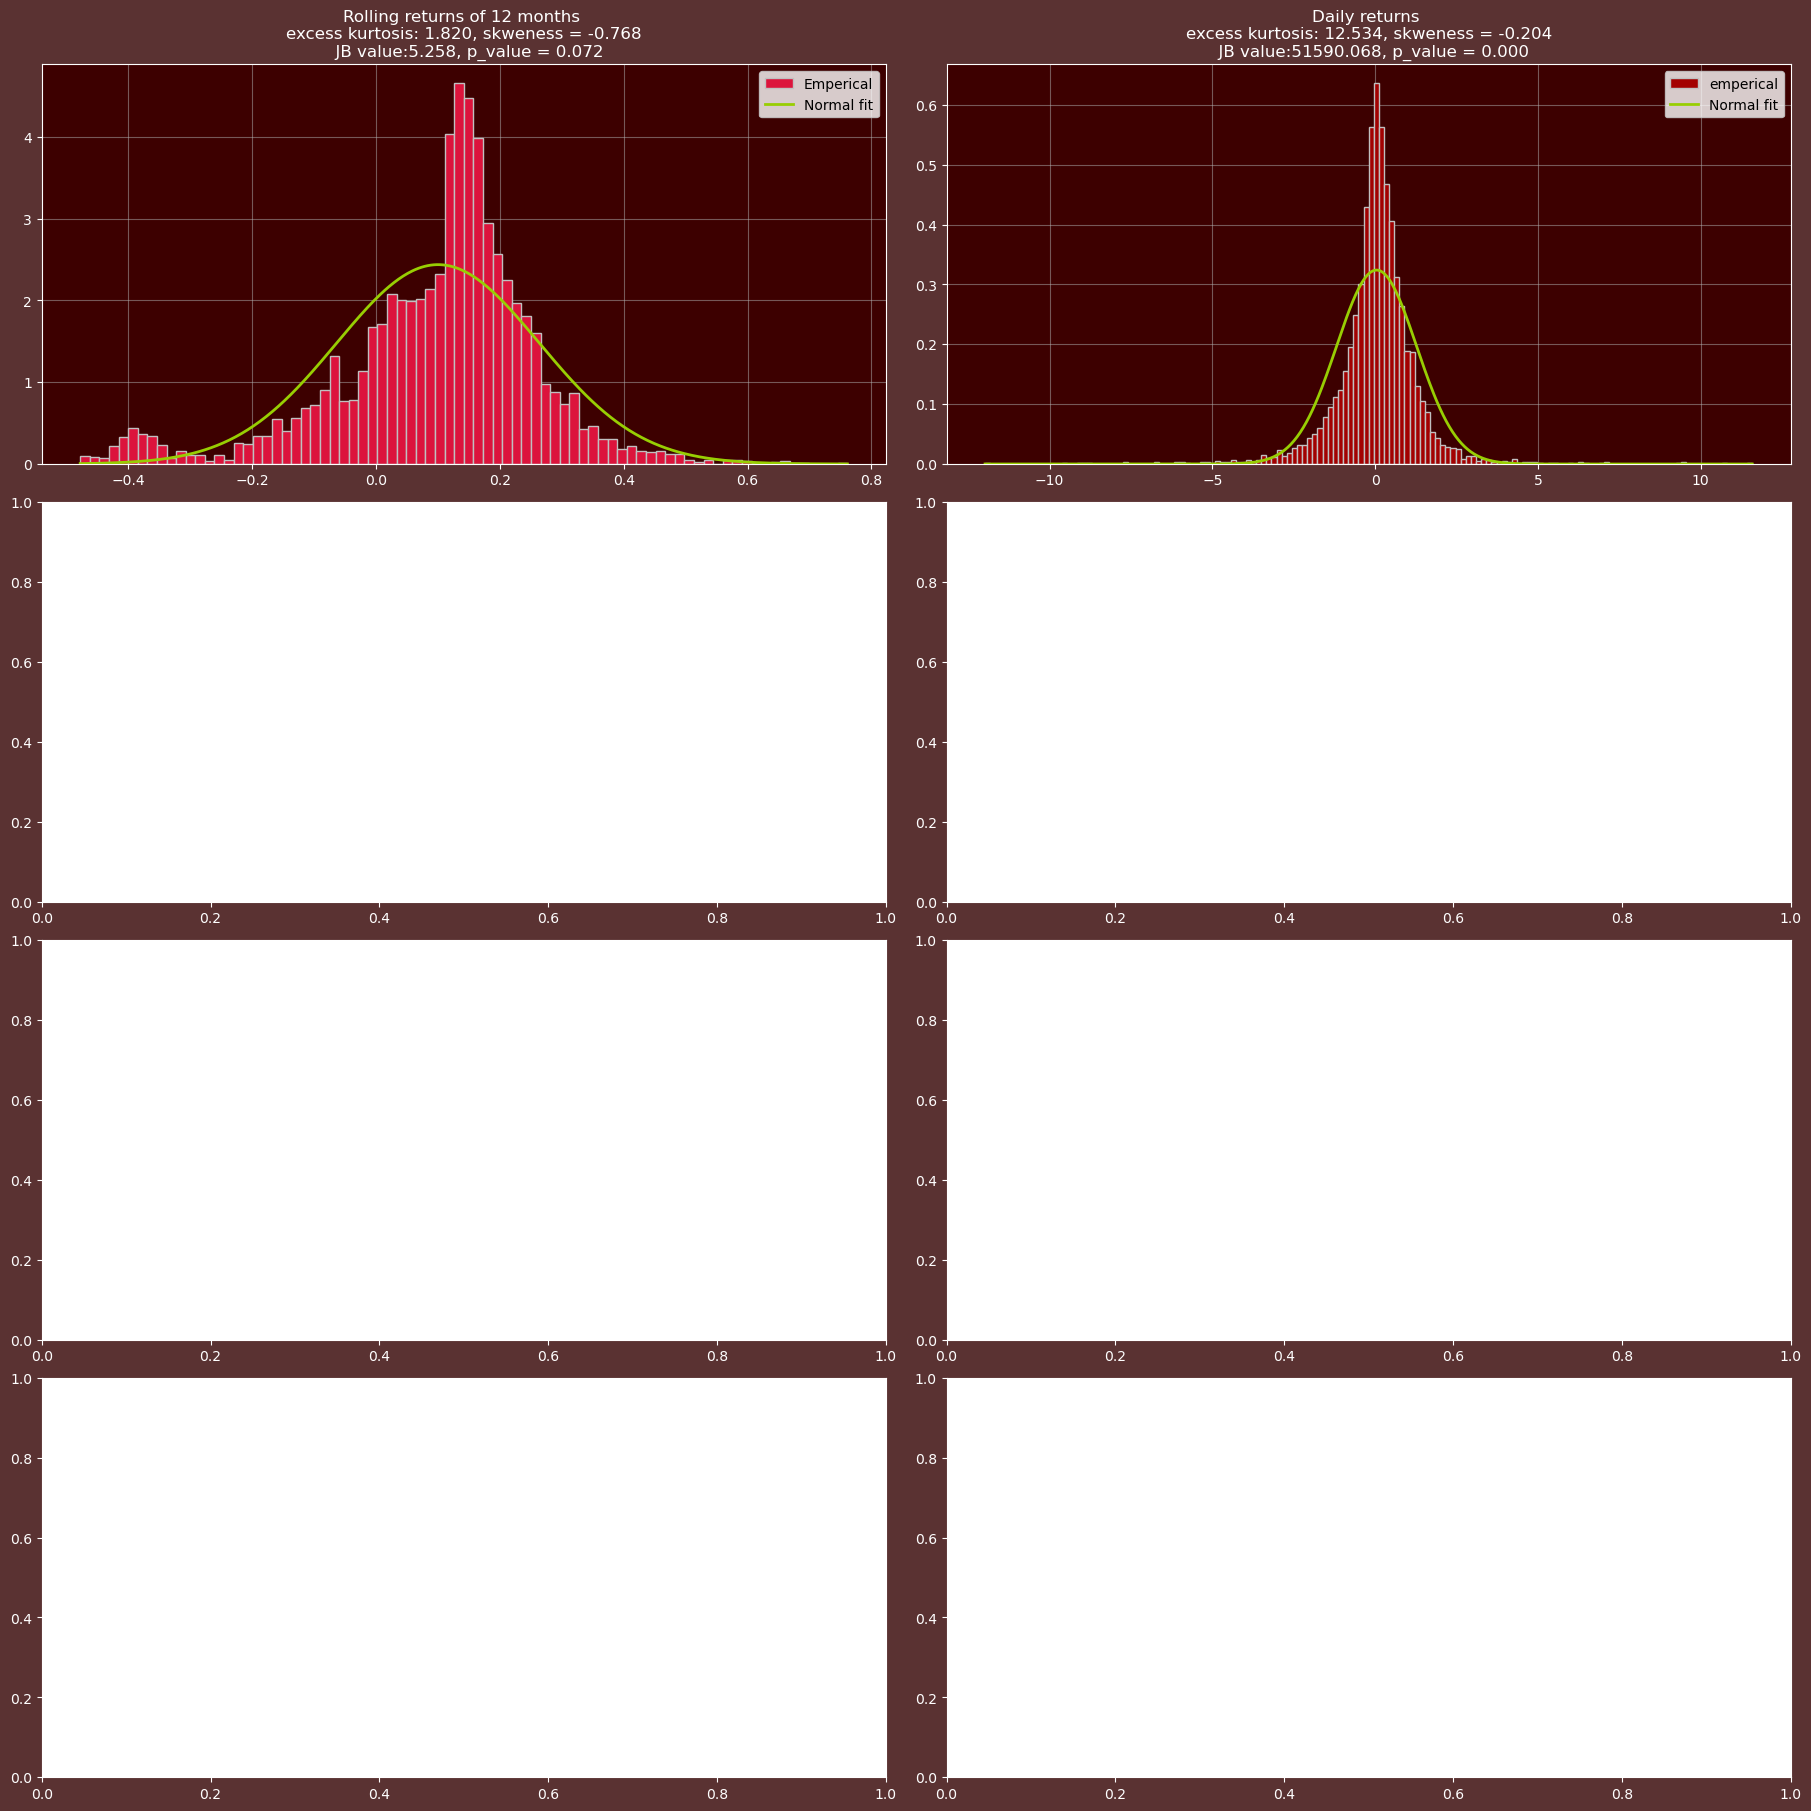

In [99]:
#now ploting the returns for looking at the distribution and normality 
def moments(datas):
    data = datas.dropna().values
    mu = data.mean()
    s = data.std(ddof = 1)
    d = data - mu
    n = len(data)
    skew = np.mean(d**3)/s**3
    ex_kurt = np.mean(d**4)/s**4 -3 
    acf_value = acf(data, nlags = 252, fft = True )[1:]
    n_eff = n/(1 + 2 * np.sum(acf_value))
    JB = skew**2*(n_eff/6) + ex_kurt**2*(n_eff/24)
    p_value = 1 - stats.chi2.cdf(JB, df=2)
    return skew, ex_kurt, JB, p_value
skew_d, kurt_d, JB_d, p_value_d = moments(d)
skew_r, kurt_r, JB_r, p_value_r= moments(r)


fig, axes = plt.subplots(4,2, figsize=(18,18), layout = "constrained")
fig.set_facecolor("#330202CE")
import matplotlib.pyplot as plt

# Set all text and decoration elements to white
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': 'white',
    'axes.titlecolor': 'white'  # Only for Matplotlib 3.4+
})
ax1 = axes[0][0]#rolling return plot
ax1.patch.set_facecolor("#3d0000")
ax1.hist(r, bins = 80,density = True, color ="crimson", label = "Emperical",edgecolor = "silver", zorder= 2)
x_range = np.linspace(r.min(), r.max(), 500)
x_normal = stats.norm.pdf(x_range, r.mean(), r.std())
ax1.plot(x_range, x_normal, lw = 2, color = "#98ce03", label = "Normal fit", zorder = 3)
ax1.legend()
ax1.grid(True,alpha = 0.5)
ax1.set_title('Rolling returns of 12 months \n' \
                f'excess kurtosis: {kurt_r:.3f}, skweness = {skew_r:.3f}\n  JB value:{JB_r:.3f}, p_value = {p_value_r:.3f}')

ax2 = axes[0][1]#daily returns
ax2.patch.set_facecolor("#3d0000")
ax2.hist(final["Daily_return_pct"], bins = 150, density = True,label ="emperical", color = "#a30101", edgecolor = "silver", zorder = 2)
x_range = np.linspace(d.min(), d.max(), 500)
x_normal = stats.norm.pdf(x_range, d.mean(), d.std())
ax2.plot(x_range, x_normal, lw = 2, color = "#98ce03", label = "Normal fit", zorder = 3)
ax2.legend()
ax2.grid(True, alpha = 0.5)
ax2.set_title('Daily returns \n' \
                f'excess kurtosis: {kurt_d:.3f}, skweness = {skew_d:.3f}\n  JB value:{JB_d:.3f}, p_value = {p_value_d:.3f}')


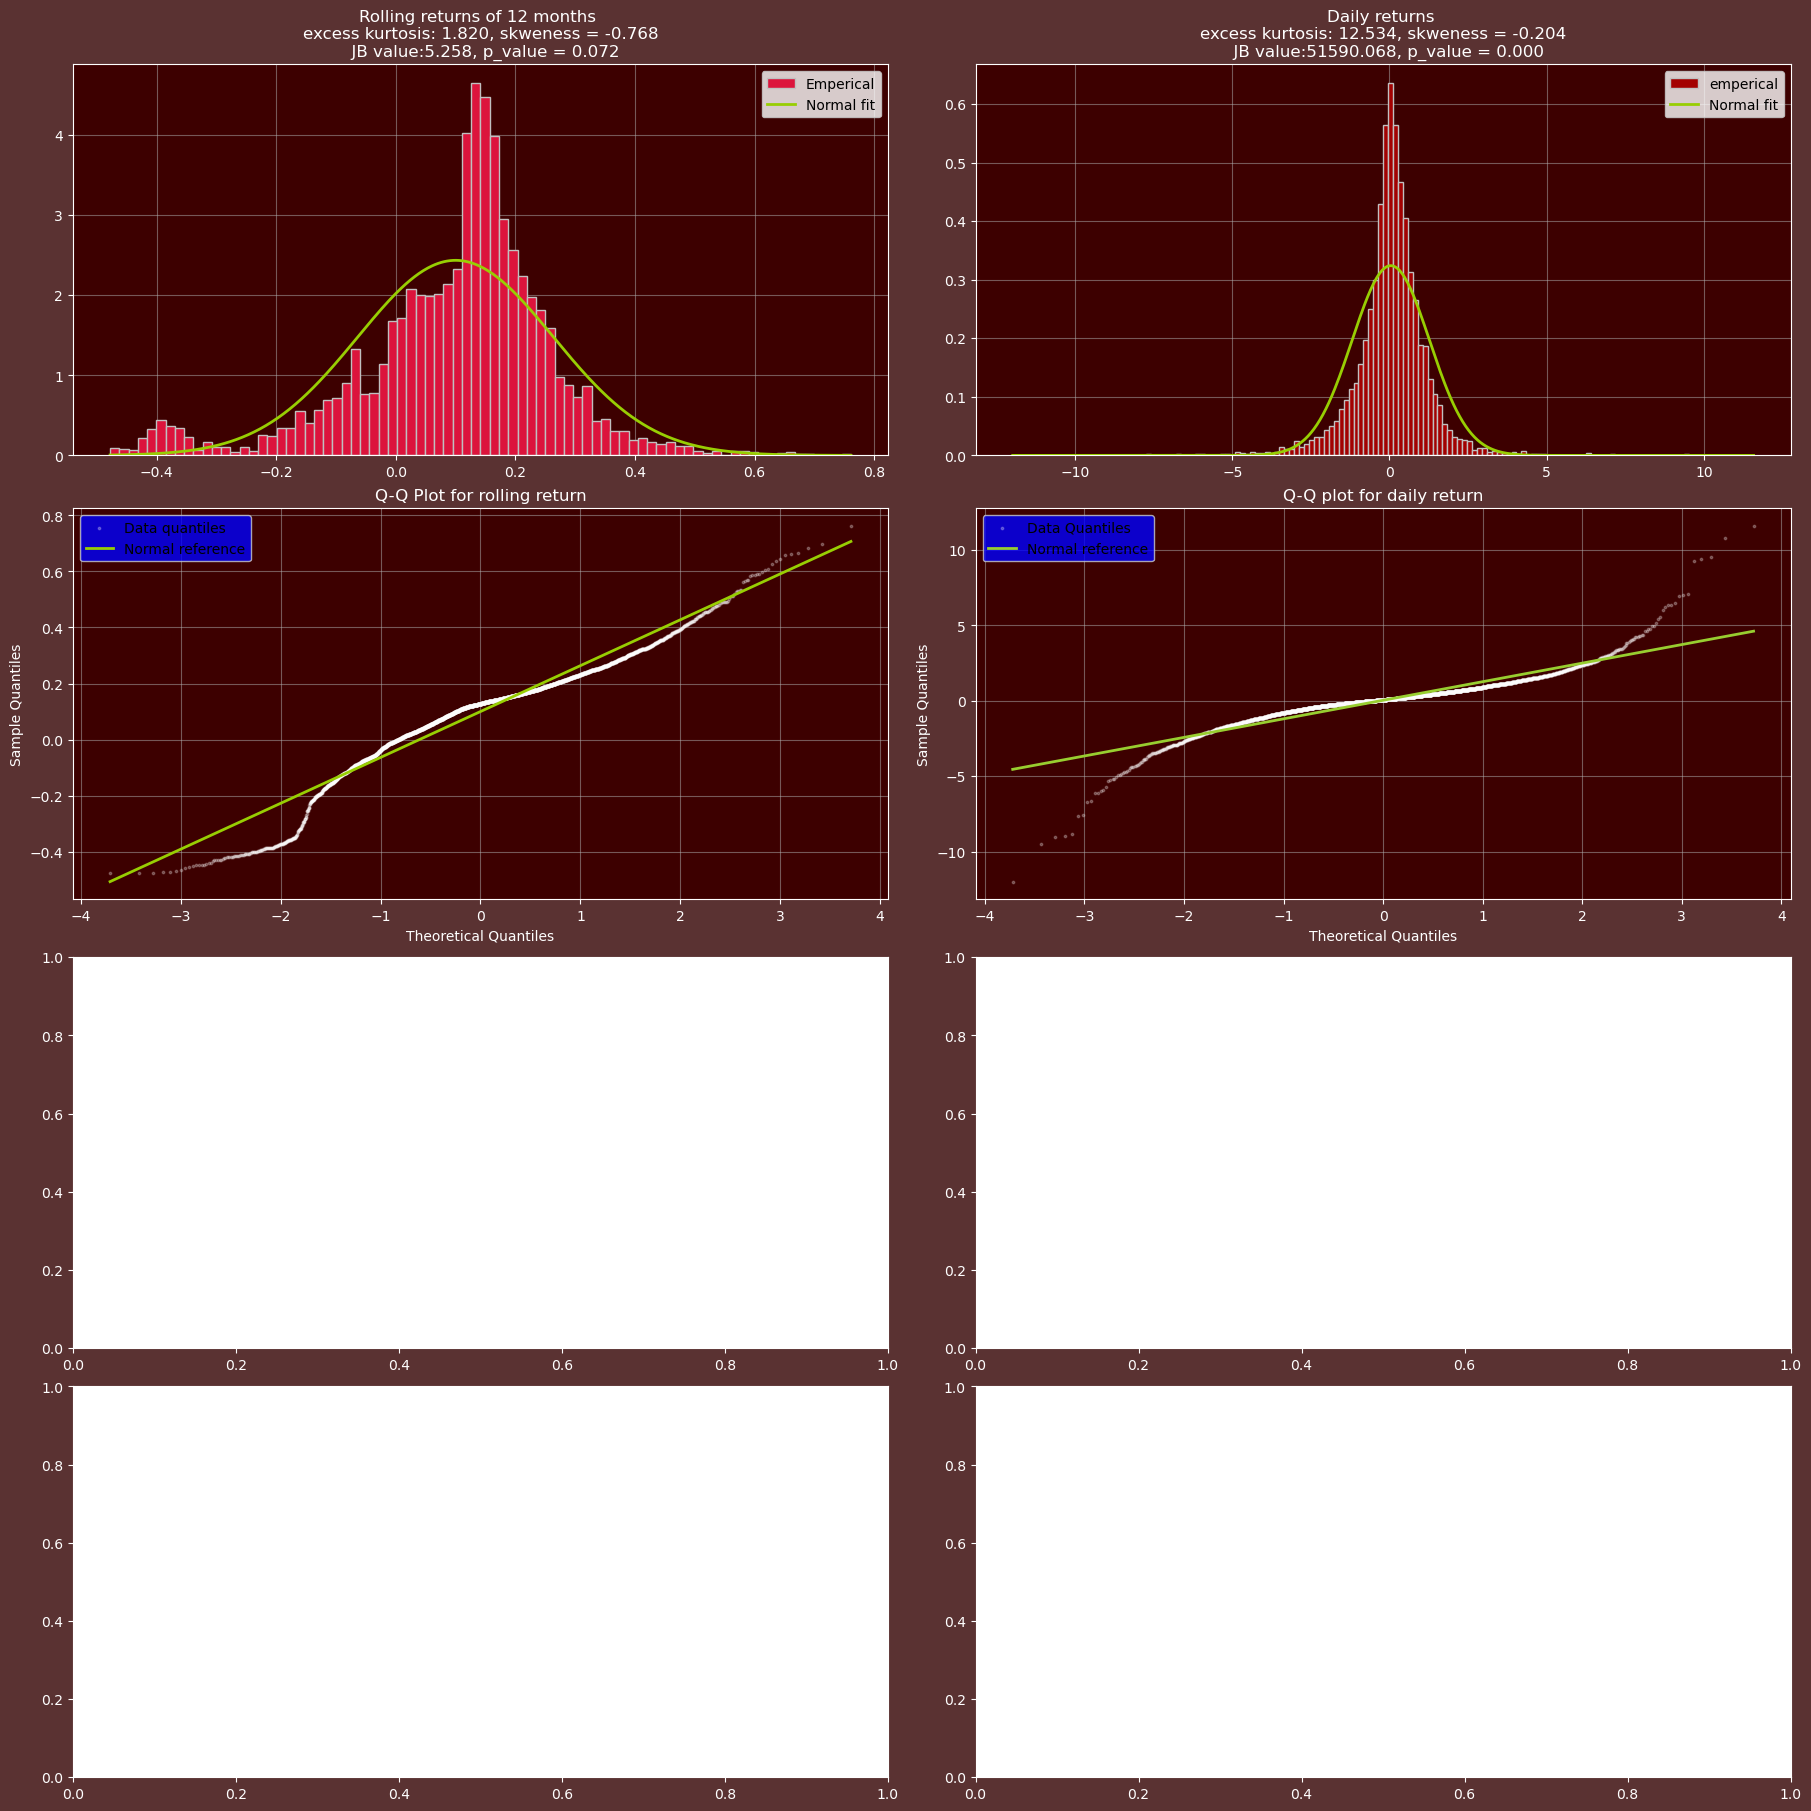

In [100]:
'''import sympy as sp 

def error_function(x):
    t = sp.Symbol('t')
    f = sp.exp(-(t**2))
    result = 2/sp.sqrt(sp.pi)  * sp.integrate(f,(t, 0, x ))
    return result

def inv_error(t):
    x = sp.Symbol('x')
    y = sp.Symbol('y')
    f = error_function(x)
    inverse_list = sp.solve(sp.Eq(y, f),x)
    inv_err = inverse_list[0].subs(y,t)
    result = inv_err.evalf()
    return float(result)

def inverse_cdf(p):
    return math.sqrt(2)*inv_error(2*p-1)

def theoretical_qunatiles(data):
    data = data.dropna()
    sorted_data = sorted(data.tolist())
    n = len(data)
    rank = np.arange(1,n+1)
    probabilities = (rank-0.5)/n
    theoretical_quantiles = [inverse_cdf(p)for p in probabilities]
    mean = np.mean(sorted_data)
    sd = np.std(sorted_data)
    x = np.linspace(np.min(theoretical_quantiles), np.max(theoretical_quantiles),100)
    y = x * sd + mean
    return theoretical_quantiles, sorted_data, x, y
#now creating some of visuals 
theoretical_qunatiles_r, sorted_data_r, x_r, y_r = theoretical_qunatiles(r)
theoretical_qunatiles_d, sorted_data_d, x_d, y_d = theoretical_qunatiles(d)
'''
from scipy import stats
def theoretical_qunatiles(data):
    data = data.dropna()
    sorted_data = sorted(data.tolist())
    n = len(data)
    rank = np.arange(1,n+1)
    probabilities = (rank-0.5)/n
    theoretical_quantiles = [stats.norm.ppf(p)for p in probabilities]
    mean = np.mean(sorted_data)
    sd = np.std(sorted_data)
    x = np.linspace(np.min(theoretical_quantiles), np.max(theoretical_quantiles),100)
    y = x * sd + mean
    return theoretical_quantiles, sorted_data, x, y
#now creating some of visuals 
theoretical_qunatiles_r, sorted_data_r, x_r, y_r = theoretical_qunatiles(r)
theoretical_qunatiles_d, sorted_data_d, x_d, y_d = theoretical_qunatiles(d)

ax3 = axes[1][0]
ax3.patch.set_facecolor("#3d0000")

#(osm, osr), (slope, intercept, _) = stats.probplot(sorted_data, dist='norm')
#osm = np.array(osm); osr = np.array(osr)

ax3.scatter(theoretical_qunatiles_r, sorted_data_r, color="#ffffff", alpha=0.25, s=3,
            label='Data quantiles', zorder=2)
ax3.plot(x_r,y_r,
         color="#98ce03", lw=2, label='Normal reference', zorder=3)

ax3.set_xlabel("Theoretical Quantiles")
ax3.set_ylabel("Sample Quantiles")
ax3.set_title("Q-Q Plot for rolling return")
ax3.legend(facecolor = "blue")
ax3.grid(True, alpha = 0.5)

ax4 = axes[1][1]
ax4.patch.set_facecolor("#3d0000")
ax4.scatter(theoretical_qunatiles_d, sorted_data_d, color = "#ffffff",alpha = 0.25, s = 3, label = 'Data Quantiles', zorder = 2)
ax4.plot(x_d, y_d, color = "#98ce30" , lw =2, label = 'Normal reference', zorder = 3)
ax4.set_xlabel("Theoretical Quantiles")
ax4.set_ylabel("Sample Quantiles")
ax4.set_title("Q-Q plot for daily return")
ax4.legend(facecolor = "blue")
ax4.grid(True, alpha = 0.5)
display(fig)

C:\Users\BROTHER COMPUTER\AppData\Local\Temp\ipykernel_9740\1866538076.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  n_eff = n/(1 + 2 * np.sum(acf_value))


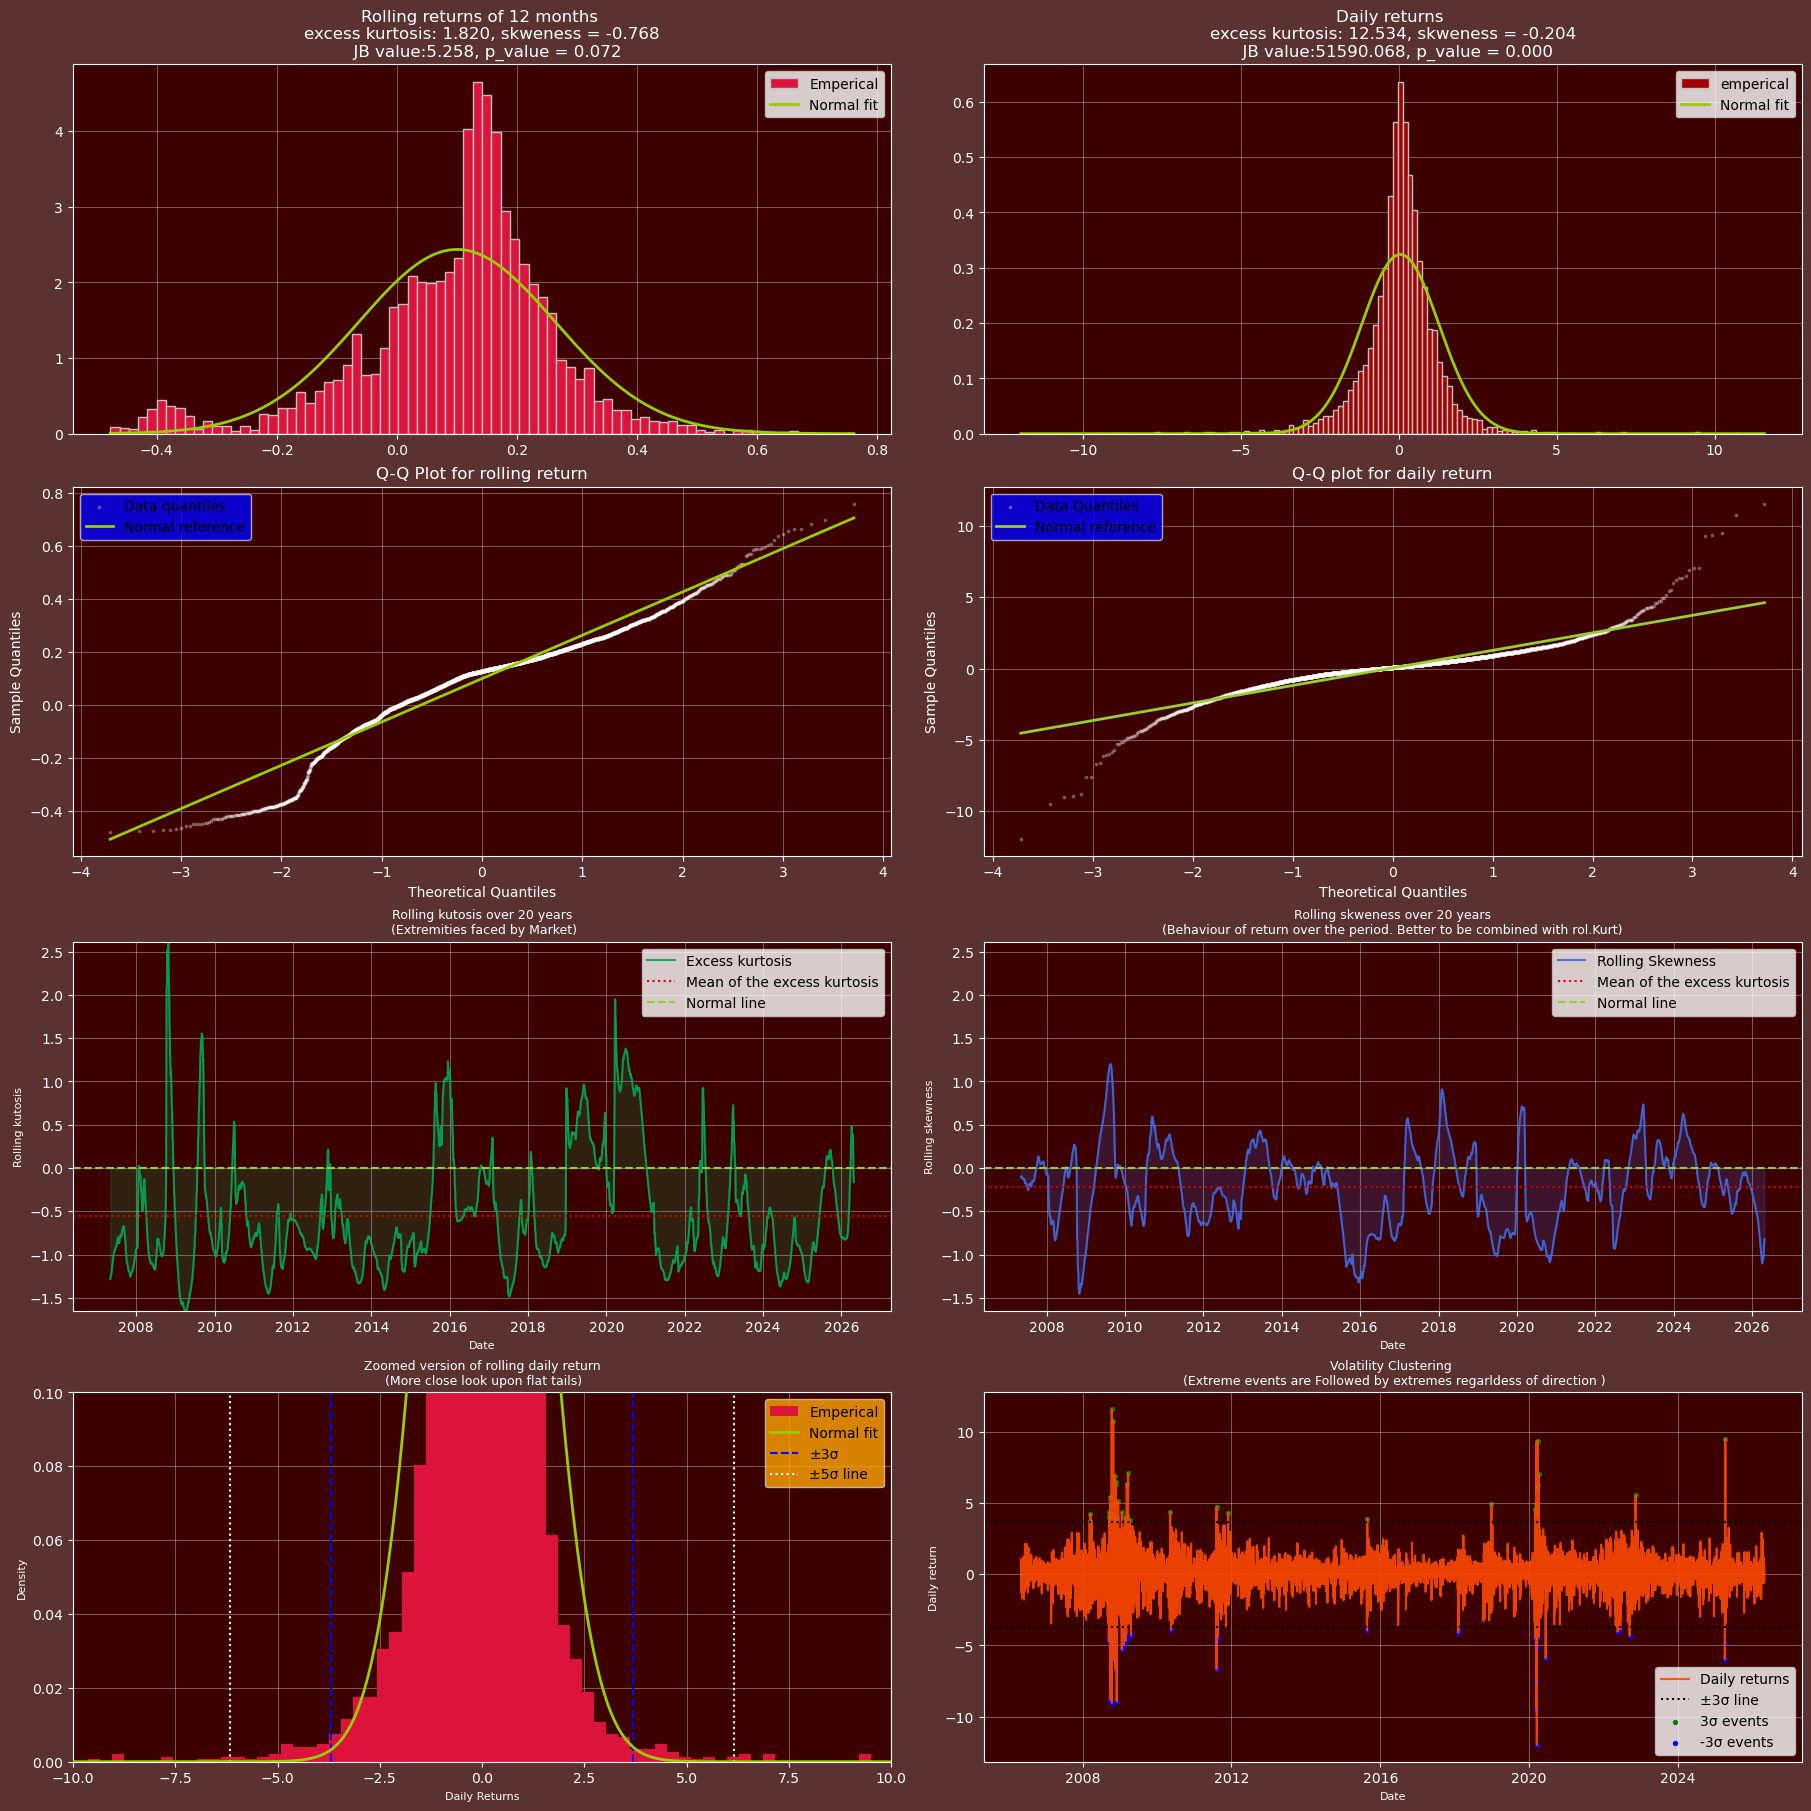

In [101]:
ax5.clear()
ax6.clear()
ax7.clear()
ax8.clear()



def rolling_kurt(data, window_period):
    kurts = []
    skew = []
    for i in range(len(data)):
        if i < window_period-1:
            kurts.append(np.nan)
            skew.append(np.nan)
        else:
            r_k = data[i - window_period + 1 :  i + 1]
            r_s, rolling_kurt, _ , _ =  moments(r_k)
            kurts.append(rolling_kurt)
            skew.append(r_s)
    return pd.Series(kurts), pd.Series(skew)

rolling_kurt, rolling_skew= rolling_kurt(final["Adj Close"], 252)
index = final["Date"]
y_min =  min(min(rolling_kurt.dropna()), min(rolling_skew.dropna()))
y_max =  max(max(rolling_kurt.dropna()),max(rolling_skew.dropna()))
ax5 = axes[2][0]
ax5.patch.set_facecolor("#3d0000")
ax5.plot( index , rolling_kurt, color = "#00a854", alpha = 0.9, label = "Excess kurtosis", zorder = 2)
ax5.fill_between(index,0,rolling_kurt.values, where = rolling_kurt.values, color = "#00a854", alpha = 0.2 )
ax5.axhline(np.nanmean(rolling_kurt), color = "#d60202", linestyle = ":",label = "Mean of the excess kurtosis")
ax5.axhline(0, color =  "#98ce30", linestyle = "--", label = "Normal line")
ax5.set_ylim(y_min, y_max)
ax5.set_xlabel("Date",fontsize = 8)
ax5.set_ylabel("Rolling kutosis",fontsize = 8)
ax5.set_title("Rolling kutosis over 20 years\n (Extremities faced by Market)",fontsize = 9)
ax5.grid(True, alpha = 0.5)
ax5.legend()



ax6 = axes[2][1]
ax6.patch.set_facecolor("#3d0000")
ax6.plot(index, rolling_skew, color = "#4169E1", alpha = 0.9, label = "Rolling Skewness")
ax6.fill_between(index, 0 , rolling_skew.values, where = rolling_skew.values , color = "#4169E1", alpha = 0.2)
ax6.axhline(np.nanmean(rolling_skew), color = "#d60202", linestyle = ":",label = "Mean of the excess kurtosis")
ax6.axhline(0, color =  "#98ce30", linestyle = "--", label = "Normal line")
ax6.set_ylim( y_min, y_max)
ax6.set_xlabel("Date", fontsize = 8)
ax6.set_ylabel("Rolling skewness", fontsize = 8)
ax6.set_title("Rolling skweness over 20 years\n (Behaviour of return over the period. Better to be combined with rol.Kurt) ", fontsize = 9)
ax6.legend()
ax6.grid(True, alpha = 0.5)


ax7 = axes[3][0]
ax7.patch.set_facecolor("#3d0000")
ax7.hist(d, bins = 80,density = True, color ="crimson", label = "Emperical", zorder= 2)
x_range = np.linspace(d.min(), d.max(), 500)
x_normal = stats.norm.pdf(x_range, d.mean(), d.std())
ax7.plot(x_range, x_normal, lw = 2, color = "#98ce03", label = "Normal fit", zorder = 3)
ax7.set_xlim(-10, 10)
ax7.set_ylim(0 , 0.1)
v = 3 * d.std()
p = 5 * d.std()
ax7.axvline(v, color = "blue", label = ("±3σ"), linestyle = "--")
ax7.axvline(-v, color = "blue", linestyle = "--")
ax7.axvline(p, color = "white", linestyle = ":", label = "±5σ line")
ax7.axvline(-p, color = "white", linestyle = ":")
ax7.set_xlabel("Daily Returns",fontsize = 8)
ax7.set_ylabel("Density", fontsize = 8)
ax7.set_title("Zoomed version of rolling daily return\n (More close look upon flat tails)",fontsize = 9)
ax7.legend(facecolor = "orange")
ax7.grid(True, alpha = 0.5)

ax8 = axes[3][1]
ax8.patch.set_facecolor("#3d0000")
ax8.plot(final["Date"],d.values, color = "#ff4901", alpha = 0.9, label = "Daily returns")
extr_pos = d[d> 3*d.std()]
extr_pos_index = date[d > 3*d.std()]
extr_neg = d[d< -3*d.std()]
extr_neg_index = date[d < -3*d.std()]
ax8.axhline(v, color = "black", linestyle = ":", label = "±3σ line")
ax8.axhline(-v, color = "black", linestyle = ":")

ax8.scatter(extr_pos_index, extr_pos.values, color = "green" , label = "3σ events", s = 8)
ax8.scatter(extr_neg_index, extr_neg.values, color = "blue" , label = "-3σ events", s = 8)
ax8.set_xlabel("Date",fontsize = 8)
ax8.set_ylabel("Daily return", fontsize = 8)
ax8.set_title("Volatility Clustering \n (Extreme events are Followed by extremes regarldess of direction )", fontsize = 9)
ax8.legend()
ax8.grid(True, alpha = 0.5)

fig.savefig('S&P500.png')
display(fig)
